# Exploratory Data Analysis (EDA) - ISPU Jakarta Dataset

Analisis visual dataset ISPU yang telah dibersihkan.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load Data
try:
    df = pd.read_csv('dataset/ispu_cleaned.csv', parse_dates=['tanggal'])
    print(f"Data Loaded. Shape: {df.shape}")
    print(f"Date Range: {df['tanggal'].min().date()} to {df['tanggal'].max().date()}")
except FileNotFoundError:
    print("dataset/ispu_cleaned.csv not found. Please run the cleaning notebook first.")
    
df.info()

Data Loaded. Shape: (15412, 11)
Date Range: 2010-01-01 to 2025-08-31
<class 'pandas.DataFrame'>
RangeIndex: 15412 entries, 0 to 15411
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   tanggal             15085 non-null  datetime64[us]
 1   stasiun             15410 non-null  str           
 2   pm10                14703 non-null  float64       
 3   pm25                6611 non-null   float64       
 4   so2                 15111 non-null  float64       
 5   co                  15204 non-null  float64       
 6   o3                  15067 non-null  float64       
 7   no2                 15100 non-null  float64       
 8   max                 15412 non-null  float64       
 9   critical_parameter  15366 non-null  str           
 10  target_kategori     15412 non-null  str           
dtypes: datetime64[us](1), float64(7), str(3)
memory usage: 1.3 MB


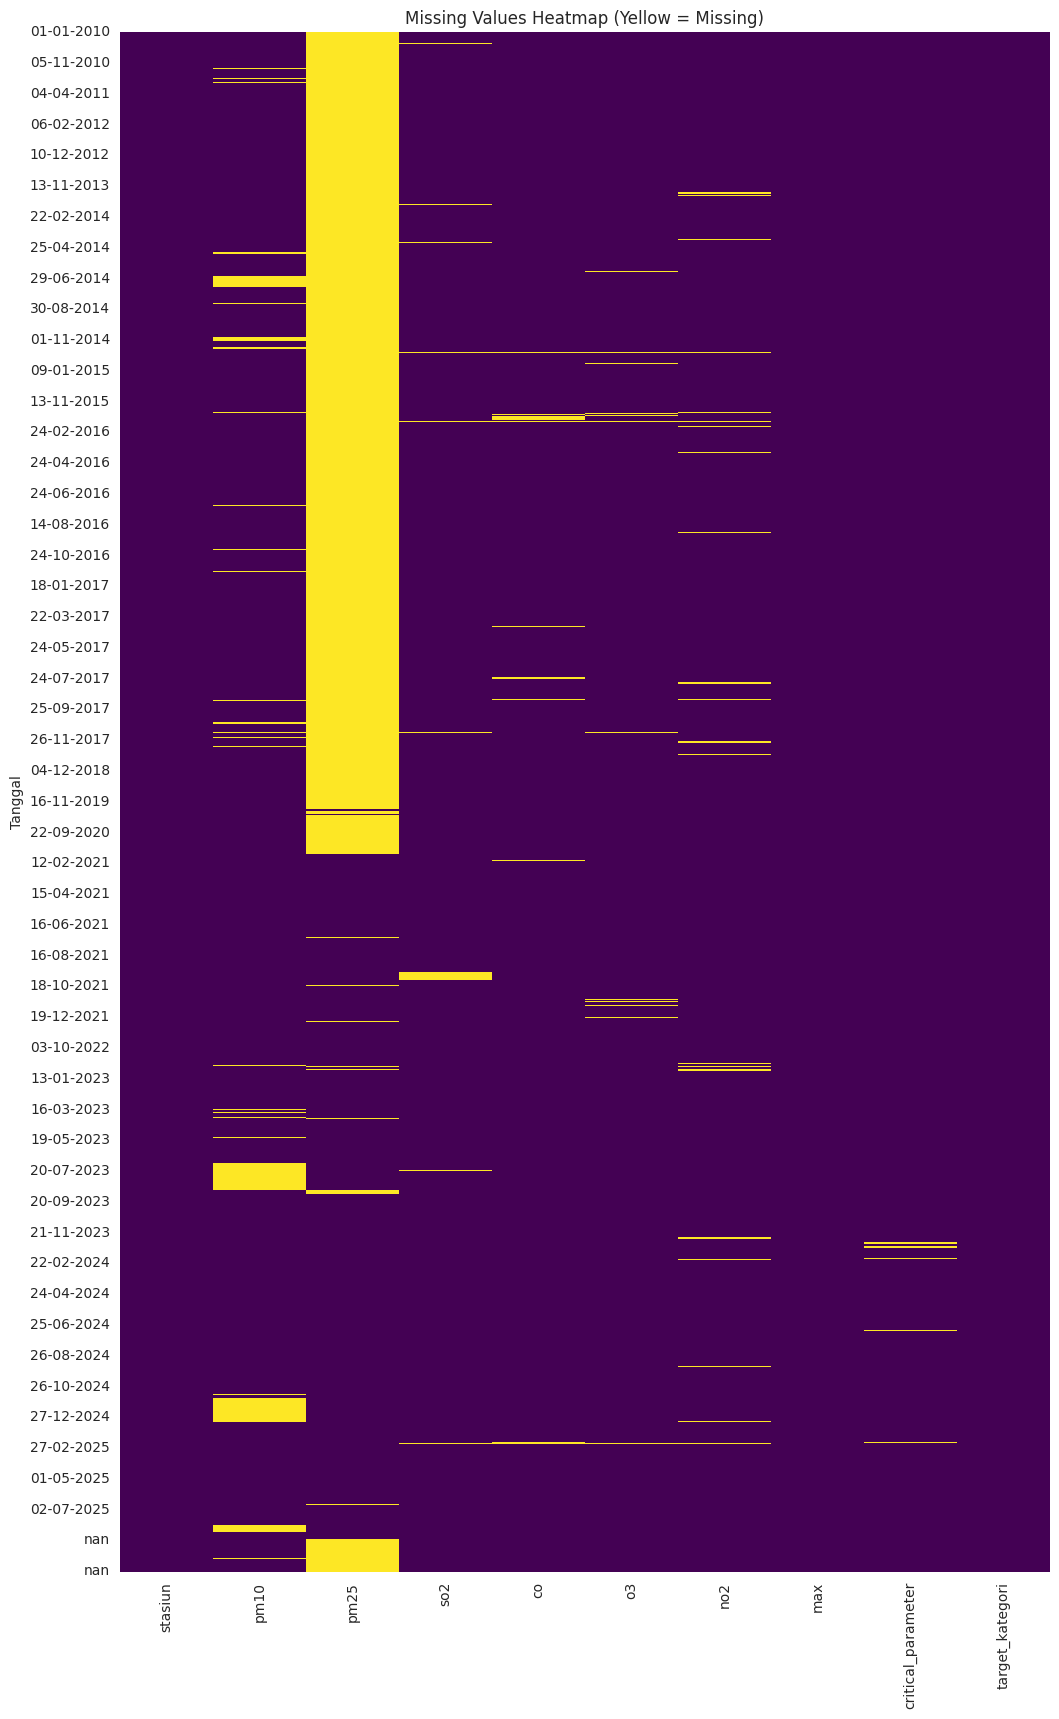

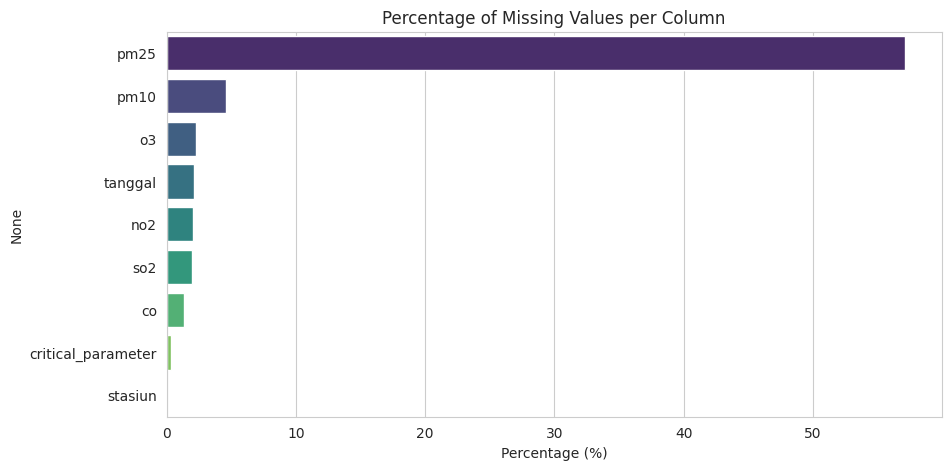

In [16]:
# Missing Values Visualization
plt.figure(figsize=(12, 20))

if 'tanggal' in df.columns:
    heatmap_data = df.set_index('tanggal')
    # Format index 'DD-MM-YYYY' as requested
    heatmap_data.index = heatmap_data.index.strftime('%d-%m-%Y') 
else:
    heatmap_data = df

ytick_freq = max(1, len(heatmap_data) // 50)  # Show ~50 dates on y-axis for better granularity

sns.heatmap(heatmap_data.isnull(), cbar=False, cmap='viridis', yticklabels=ytick_freq)
plt.title('Missing Values Heatmap (Yellow = Missing)')
plt.ylabel('Tanggal')
plt.yticks(rotation=0) 
plt.show()

# Percentage of missing values
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

if not missing_pct.empty:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_pct.values, y=missing_pct.index, hue=missing_pct.index, palette='viridis', legend=False)
    plt.title('Percentage of Missing Values per Column')
    plt.xlabel('Percentage (%)')
    plt.show()
else:
    print("No missing values found!")

In [10]:
df.isna().sum()

tanggal                327
stasiun                  2
pm10                   709
pm25                  8801
so2                    301
co                     208
o3                     345
no2                    312
max                      0
critical_parameter      46
target_kategori          0
dtype: int64

/tmp/ipykernel_32071/1985228018.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='target_kategori', data=df, order=present_order, palette='viridis')


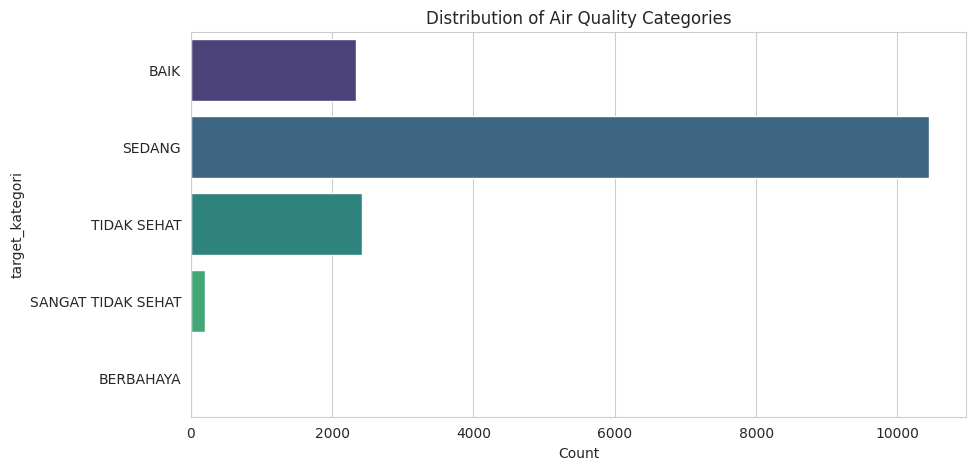

In [9]:
# 1. Target Category Distribution
plt.figure(figsize=(10, 5))
order = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
# Filter order to include only present categories to avoid errors if some are missing
present_order = [x for x in order if x in df['target_kategori'].unique()]

sns.countplot(y='target_kategori', data=df, order=present_order, palette='viridis')
plt.title('Distribution of Air Quality Categories')
plt.xlabel('Count')
plt.show()

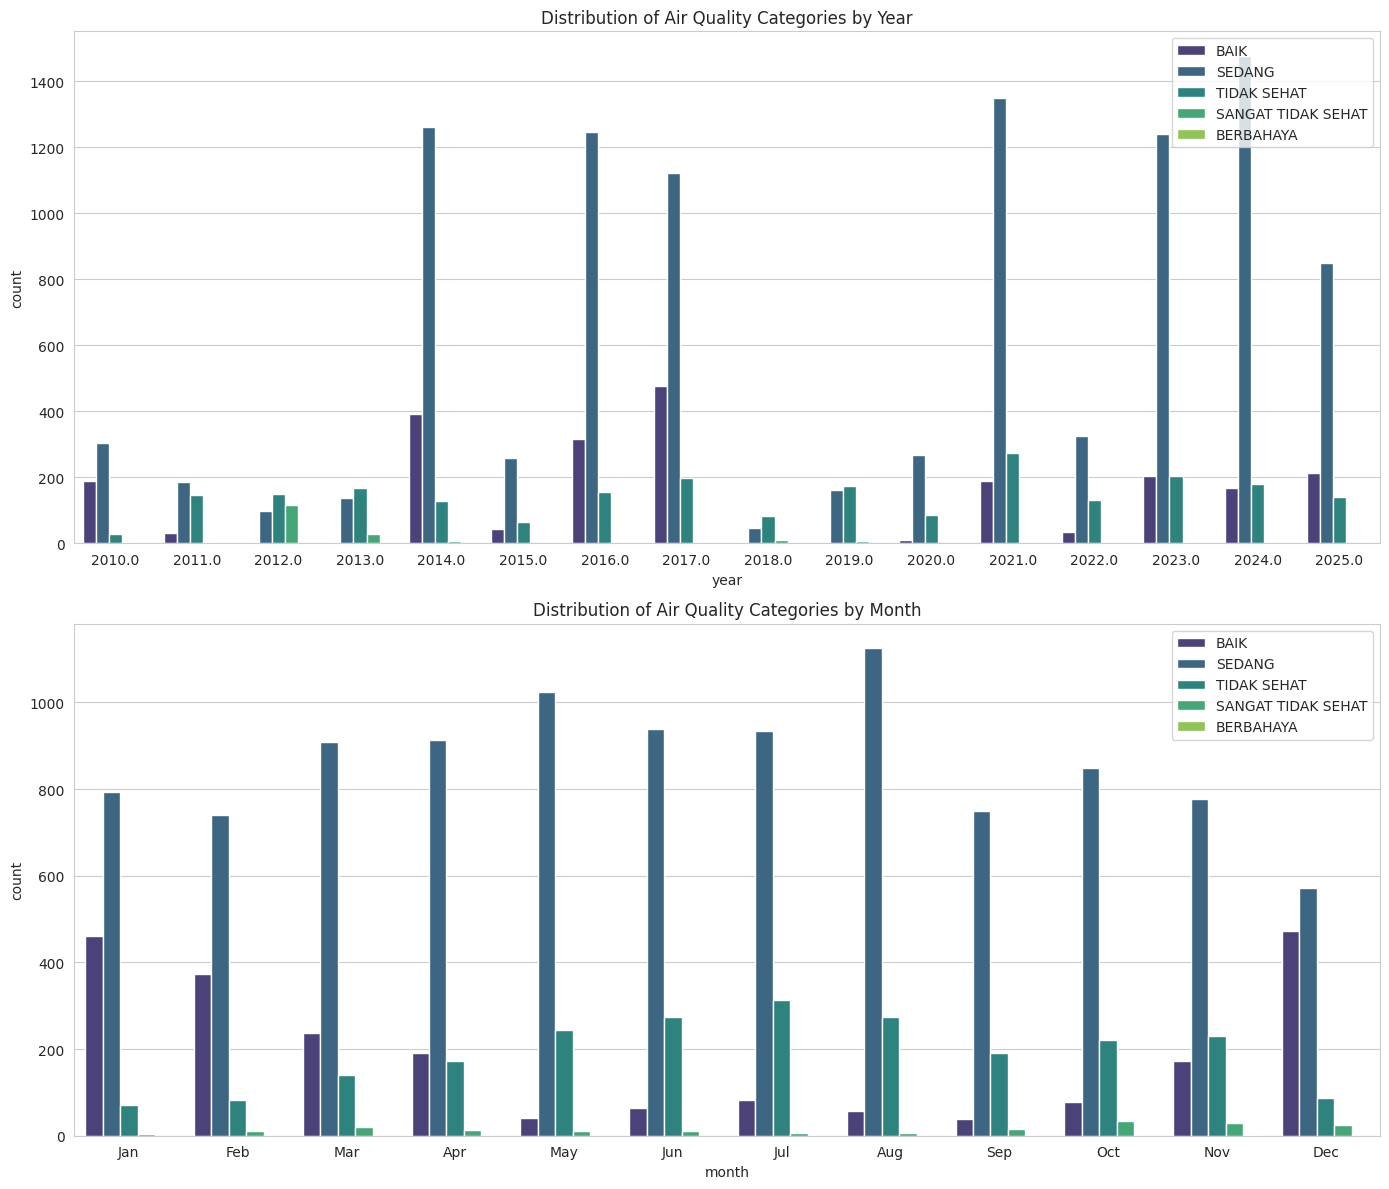

In [17]:
# Temporal Distribution (Yearly & Monthly)
df['year'] = df['tanggal'].dt.year
df['month'] = df['tanggal'].dt.month

# Ensure order is consistent
order_list = ['BAIK', 'SEDANG', 'TIDAK SEHAT', 'SANGAT TIDAK SEHAT', 'BERBAHAYA']
valid_order = [x for x in order_list if x in df['target_kategori'].unique()]

fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Yearly
sns.countplot(data=df, x='year', hue='target_kategori', hue_order=valid_order, palette='viridis', ax=axes[0])
axes[0].set_title('Distribution of Air Quality Categories by Year')
axes[0].legend(loc='upper right')

# Monthly
sns.countplot(data=df, x='month', hue='target_kategori', hue_order=valid_order, palette='viridis', ax=axes[1])
axes[1].set_title('Distribution of Air Quality Categories by Month')
axes[1].set_xticks(range(12))
axes[1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

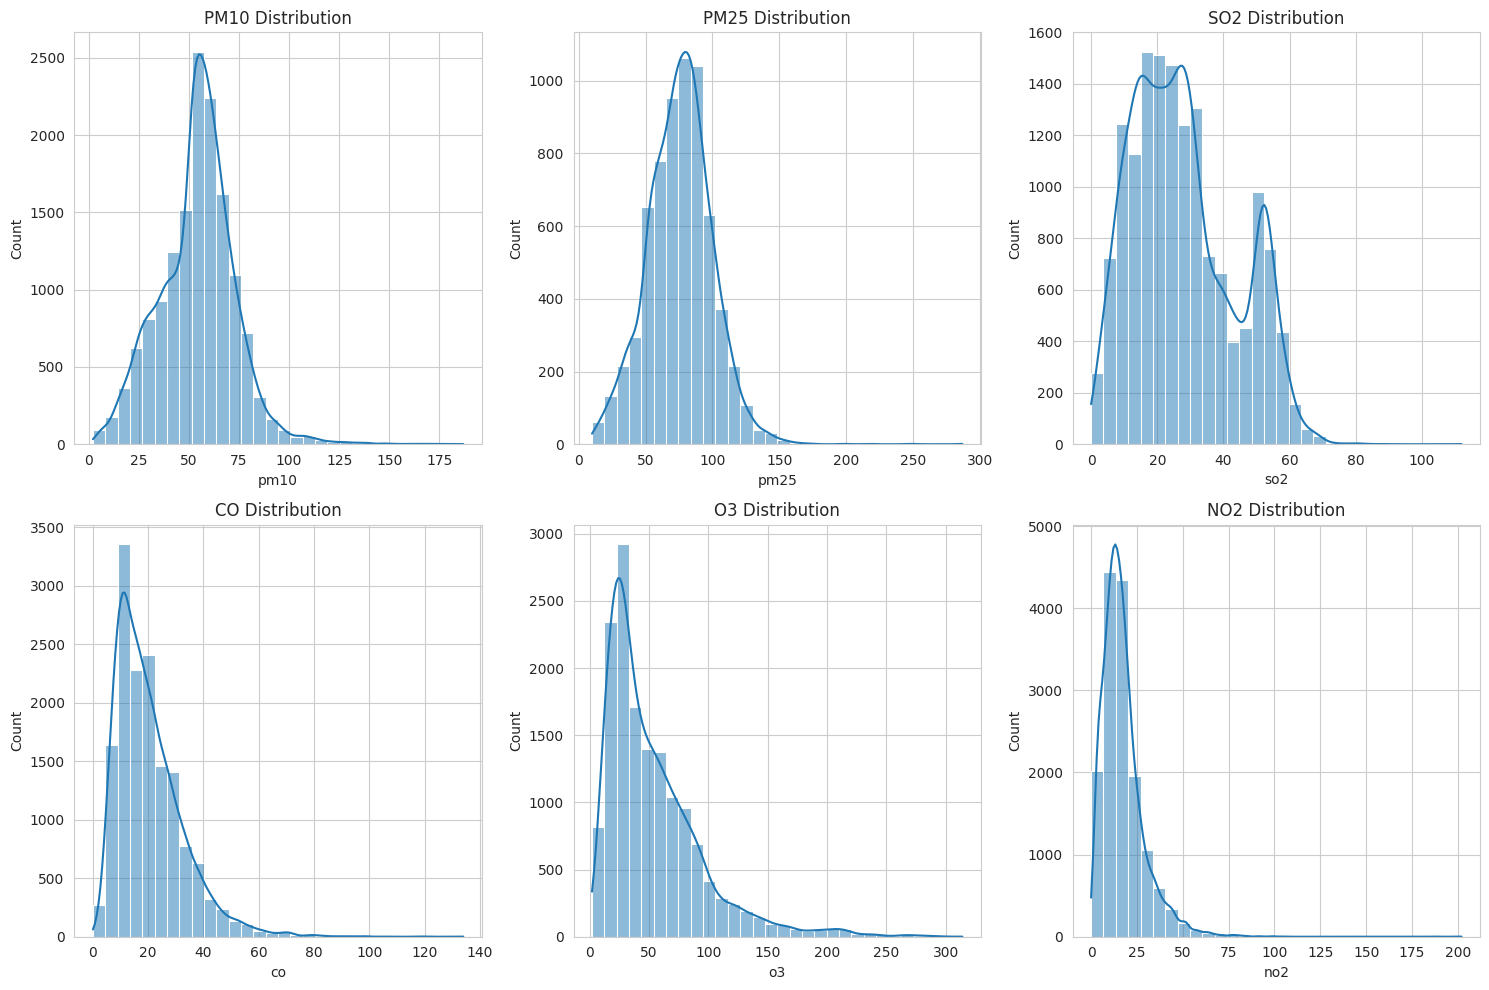

In [4]:
# 2. Pollutant Distributions
pollutants = ['pm10', 'pm25', 'so2', 'co', 'o3', 'no2']

plt.figure(figsize=(15, 10))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'{col.upper()} Distribution')
plt.tight_layout()
plt.show()

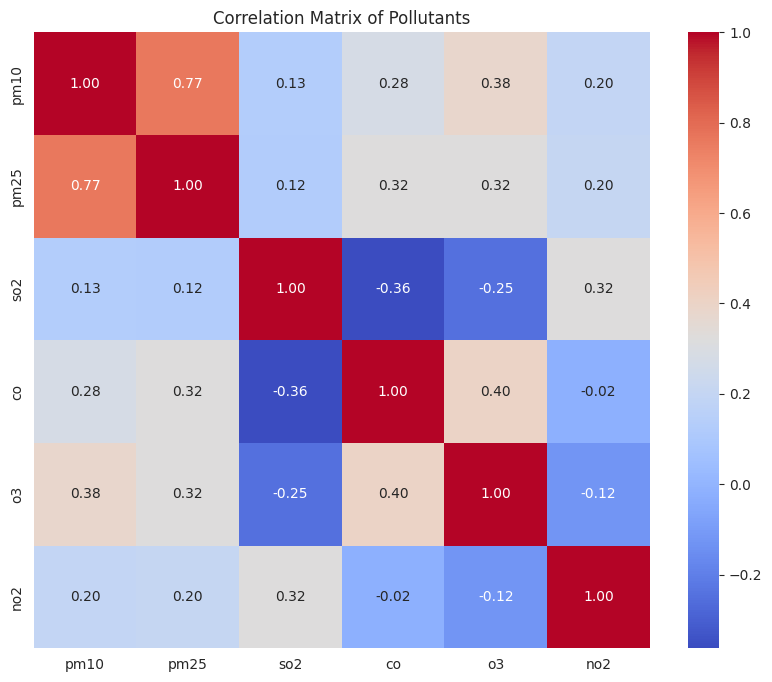

In [5]:
# 3. Correlation Matrix
plt.figure(figsize=(10, 8))
corr = df[pollutants].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', square=True)
plt.title('Correlation Matrix of Pollutants')
plt.show()

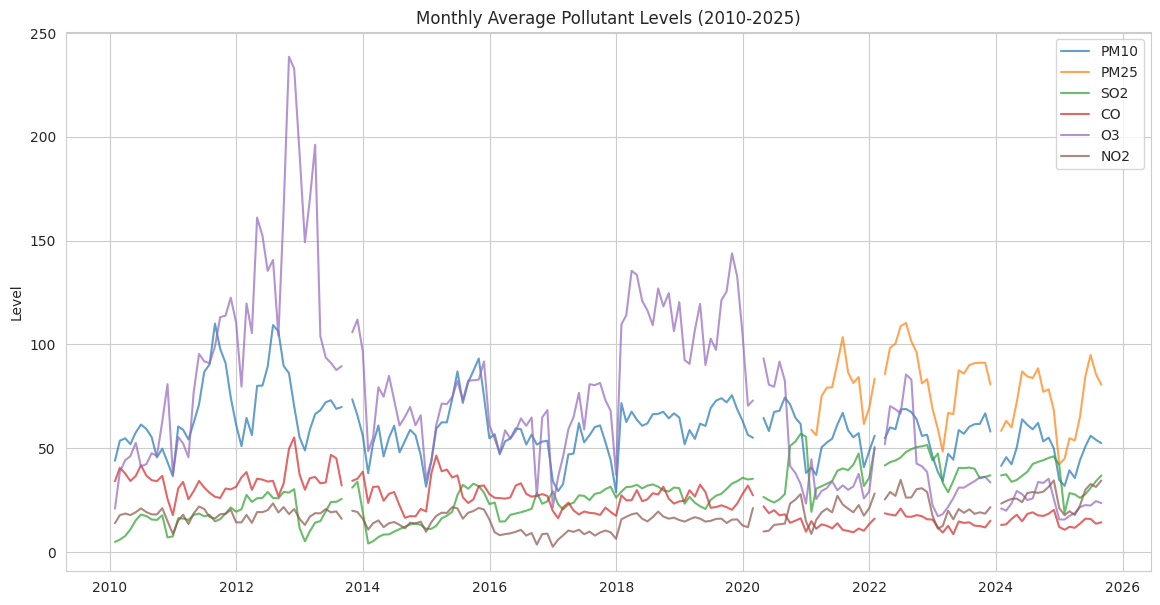

In [8]:
# 4. Time Series Trend (Monthly Average)
df_monthly = df.set_index('tanggal').resample('ME')[pollutants].mean()

plt.figure(figsize=(14, 7))
for col in pollutants:
    plt.plot(df_monthly.index, df_monthly[col], label=col.upper(), alpha=0.7)

plt.title('Monthly Average Pollutant Levels (2010-2025)')
plt.ylabel('Level')
plt.legend()
plt.show()

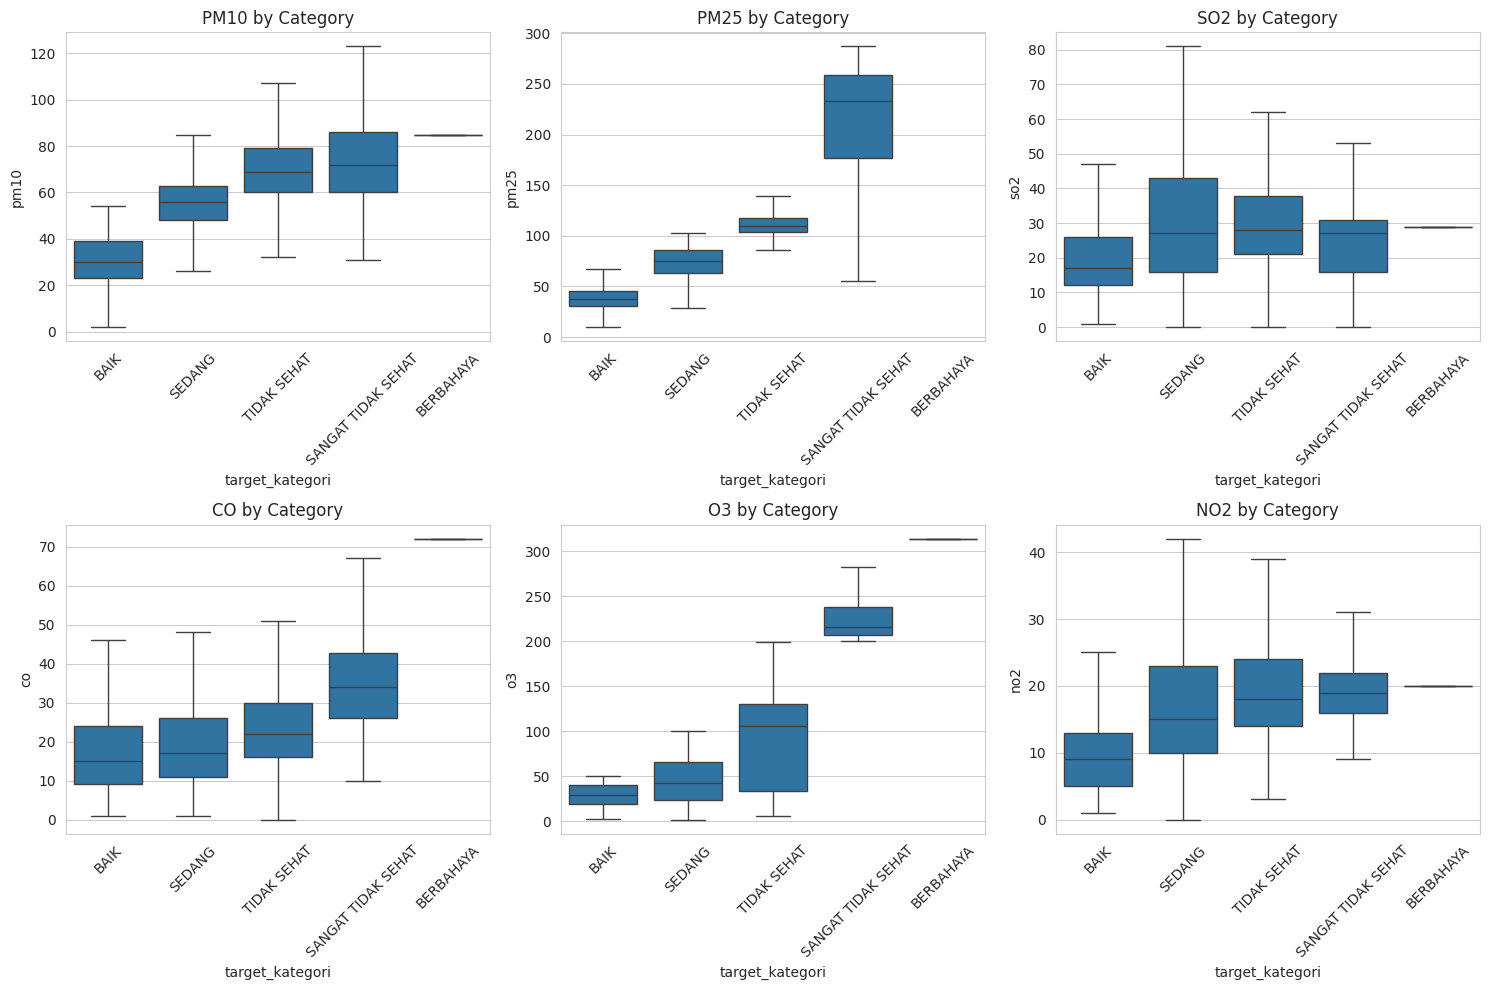

In [7]:
# 5. Pollutant Levels by Category
plt.figure(figsize=(15, 10))
for i, col in enumerate(pollutants, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='target_kategori', y=col, data=df, order=present_order, showfliers=False)
    plt.title(f'{col.upper()} by Category')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()